## **EDA**

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(),"..", "src"))
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import build_dataset as bd
import importlib
importlib.reload(bd)

from build_dataset import TARGET, LABEL_MAP

pd.set_option("display.max_colwidth", None)

**1. Understanding attack types present in dataset**

`label_by_file` lists the unique attack types and the number of rows present in each original data file. 
`label_distribution`

In [2]:
# DETERMINE ATTACK TYPES APPEARING IN EACH FILE WITH COUNTS
bd.label_by_file()

,file,n_rows,attack_types
0,Monday-WorkingHours.pcap_ISCX.csv,502573,BENIGN
1,Tuesday-WorkingHours.pcap_ISCX.csv,414134,"BENIGN, FTP-Patator, SSH-Patator"
2,Wednesday-workingHours.pcap_ISCX.csv,594193,"BENIGN, DoS GoldenEye, DoS Hulk, DoS Slowhttptest, DoS slowloris, Heartbleed"
3,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,154104,"BENIGN, Web Attack - Brute Force, Web Attack - Sql Injection, Web Attack - XSS"
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,240082,"BENIGN, Infiltration"
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,171359,"BENIGN, Bot"
6,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,204230,"BENIGN, PortScan"
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,217305,"BENIGN, DDoS"


In [3]:
# DETERMINE FREQUENCY OF EACH LABEL
bd.label_distribution()

,Label,Count,Percentage
0,BENIGN,2072254,82.96
1,DoS Hulk,172846,6.92
2,DDoS,128014,5.12
3,PortScan,90694,3.63
4,DoS GoldenEye,10282,0.41
5,FTP-Patator,5931,0.24
6,DoS slowloris,5374,0.22
7,DoS Slowhttptest,5228,0.21
8,SSH-Patator,3219,0.13
9,Bot,1948,0.08


Labels representing similar attacks are grouped together. This is because some classes are too small to evaluate on their own, and several labels represent the same type of attack. Infiltration and Heartbleed are excluded due to lack of data. 

1. DDoS
2. DoS
    DoS Hulk, DoS Golden Eye, DoS slowloris, DoS Slowhttptest
3. PortScan
4. Bot
5. BruteForce
    FTP-Patator, SSH-Patator
6. WebAttack
    Web Attack - Brute Force, Web Attack - XSS, Web Attack - Sql Injection
7. EXCLUDED
    Infiltration [36 attacks], Heartbleed [11 attacks]

In [4]:
# MAP LABELS TO GROUPS
LABEL_MAP

{'BENIGN': 'BENIGN',
 'DDoS': 'DDoS',
 'DoS Hulk': 'DoS',
 'DoS GoldenEye': 'DoS',
 'DoS slowloris': 'DoS',
 'DoS Slowhttptest': 'DoS',
 'PortScan': 'PortScan',
 'Bot': 'Bot',
 'FTP-Patator': 'BruteForce',
 'SSH-Patator': 'BruteForce',
 'Web Attack - Brute Force': 'WebAttack',
 'Web Attack - XSS': 'WebAttack',
 'Web Attack - Sql Injection': 'WebAttack',
 'Infiltration': 'EXCLUDED',
 'Heartbleed': 'EXCLUDED'}

In [5]:
df = bd.load_dataset(columns=[TARGET, "SourceFile"], label_group=True, drop_excluded=True)
print(df["LabelGroup"].value_counts(dropna=False))

LabelGroup
BENIGN        2072254
DoS            193730
DDoS           128014
PortScan        90694
BruteForce       9150
WebAttack        2143
Bot              1948
Name: count, dtype: int64


In [6]:
from IPython.display import Image

import eda
importlib.reload(eda)

from eda import GROUP_COL

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

**2. Class imbalance**

Visualizing the class imbalance.

In [7]:
# IMBALANCE RATIO AND ITS SHAPE
dist = eda.class_distribution()
ratio = eda.imbalance_ratio(dist)

print(f"Imbalance ratio (largest / smallest class): {ratio:,.1f} : 1")
print(f"BENIGN share: {dist.loc[dist[GROUP_COL] == 'BENIGN', 'Percentage'].iloc[0]}%")

Imbalance ratio (largest / smallest class): 1,063.8 : 1
BENIGN share: 82.959%


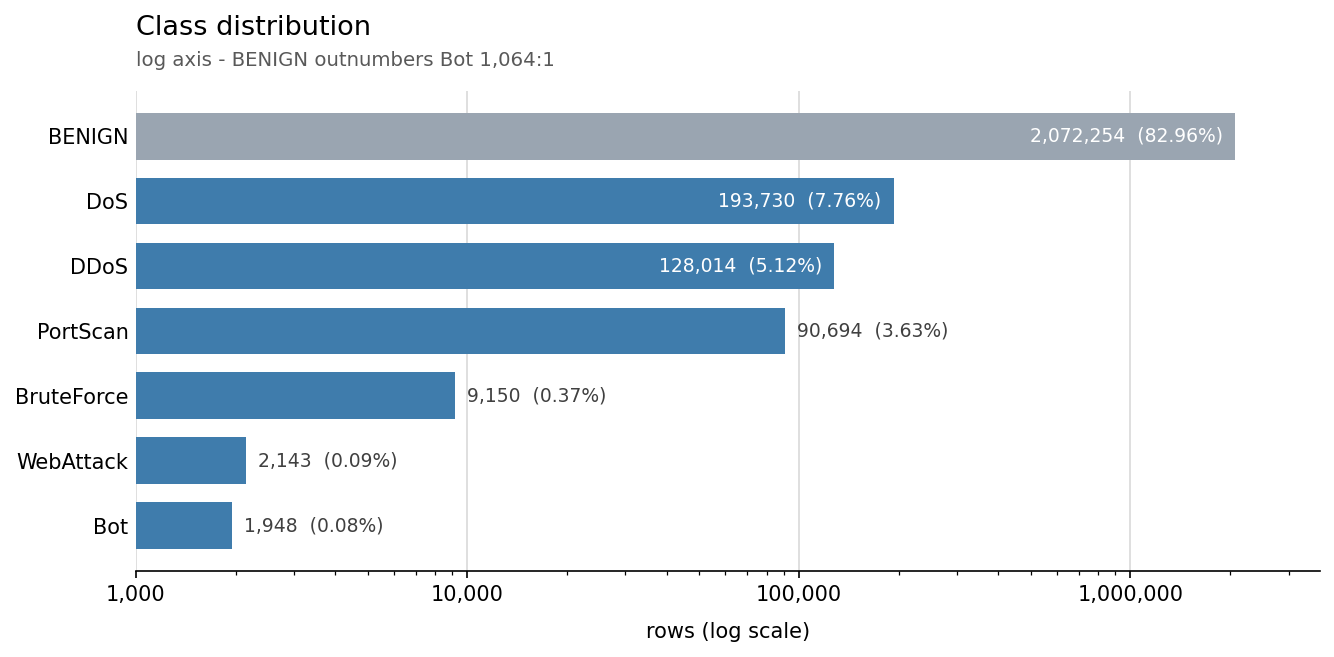

In [8]:
Image(eda.plot_class_distribution(dist))
# Plotted on a log scale axis

Since BENIGN is ~83% of the data, a model predicting entirely BENIGN would be 83% accurate. When evaluating the models, 
1. Evaluate using **Macro F-1** and **per-class precision/recall**
2. Train/test split should be **stratified** to prevent unevenly distributed classes by chance. 
3. [Optional] Cap BENIGN values in the training set. 

**3. Creating reproducible sample for distributions**

`stratified_sample` takes at most 8,000 rows per class with a fixed seed.

In [9]:
# STRATIFIED SAMPLE FOR DISTRIBUTION AND CORRELATION WORK
sample = eda.stratified_sample()
feat = eda.feature_columns()

print(f"Sample: {len(sample):,} rows x {len(feat)} features")
print(sample[GROUP_COL].value_counts().to_string())

Sample: 44,091 rows x 69 features
LabelGroup
BENIGN        8000
BruteForce    8000
DoS           8000
DDoS          8000
PortScan      8000
WebAttack     2143
Bot           1948


**4. Feature scale and skew**

Flow features mix byte counts, microsecond durations, per-second rates and
small integer flag counts in one matrix.

In [10]:
# WIDEST-RANGING FEATURES (sample)
display(eda.scale_summary(sample, feat, top=8))

skew = sample[feat].skew()
print("most skewed:")
print(skew.abs().sort_values(ascending=False).head(5).to_string())

,Min,Median,Max,Std,Range,Skew
FlowBytesS,0.0,4.319261e+02,1.035500e+09,8563723.0,1.035500e+09,80.270676
FwdIatTotal,0.0,1.010440e+05,1.200000e+08,35620552.0,1.200000e+08,1.631425
BwdIatTotal,0.0,6.300000e+01,1.200000e+08,23580428.0,1.200000e+08,3.458411
FlowDuration,1.0,1.029562e+06,1.199892e+08,35537908.0,1.199892e+08,1.614743
FwdIatMin,-1.0,3.000000e+00,1.190000e+08,6251539.5,1.190000e+08,14.314953
BwdIatMin,0.0,3.000000e+00,1.190000e+08,5421156.0,1.190000e+08,15.850449
IdleMin,0.0,0.000000e+00,1.190000e+08,32583590.0,1.190000e+08,1.978527
IdleMax,0.0,0.000000e+00,1.190000e+08,33910112.0,1.190000e+08,1.775927


most skewed:
EceFlagCount               209.978577
RstFlagCount               209.978577
TotalLengthOfBwdPackets    165.249542
SubflowFwdPackets          165.244919
TotalFwdPackets            165.244919


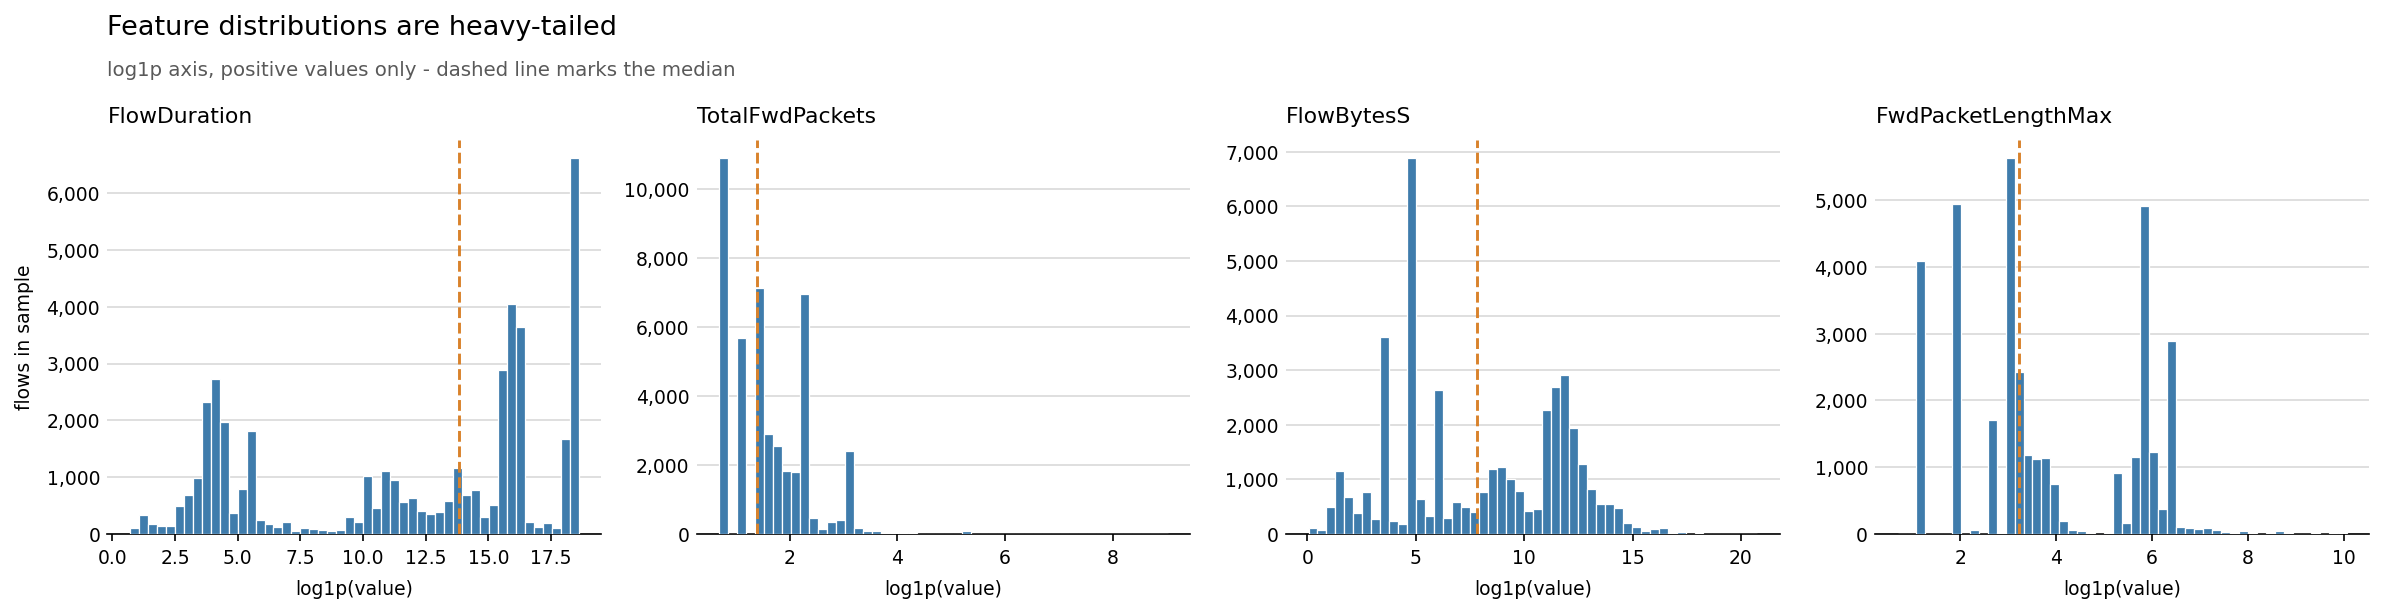

In [11]:
Image(eda.plot_feature_distributions(
    sample, ["FlowDuration", "TotalFwdPackets", "FlowBytesS", "FwdPacketLengthMax"]
))
# X-axis on a log scale

Scale matters for a linear model and not for a tree model. 
1. Wrap **logistic regression** in a StandardScaler fit on only the training fold
2. **XGBoost** is provided with raw features

**5. Data quality (cont.)**

Checking for **column signs** and impossible negatives. 

In [13]:
# NEGATIVE VALUES ON THE FULL DATASET
negatives = eda.negative_value_report()
display(negatives)

,Column,NNegative,Percentage,Min
0,InitWinBytesBackward,1194107,47.8038,-1.000000e+00
1,InitWinBytesForward,892949,35.7475,-1.000000e+00
2,FlowIatMin,2875,0.1151,-1.400000e+01
3,FlowDuration,107,0.0043,-1.300000e+01
4,FlowPacketsS,107,0.0043,-2.000000e+06
5,FlowIatMean,107,0.0043,-1.300000e+01
6,FlowIatMax,107,0.0043,-1.300000e+01
7,FlowBytesS,78,0.0031,-2.610000e+08
8,MinSegSizeForward,35,0.0014,-5.368707e+08
9,FwdHeaderLength,35,0.0014,-3.221223e+10


The top rows are **sentinels** representing when no value was observed. 

In [14]:
# HOW MUCH OF THE DATA SITS ON THE -1 SENTINEL
display(eda.sentinel_report())

,Column,NAtSentinel,Percentage,MinExcludingSentinel
0,InitWinBytesForward,892949,35.75,0.0
1,InitWinBytesBackward,1194107,47.80,0.0


**The remaining rows are corrupted** and should be calculated separately.

In [15]:
# HOW MUCH DATA IS ACTUALLY DAMAGED, SENTINEL COLUMNS EXCLUDED
n_bad, pct_bad = eda.impossible_value_rows()
print(f"rows with an impossible negative (excluding the -1 sentinel): {n_bad:,} ({pct_bad}%)")

rows with an impossible negative (excluding the -1 sentinel): 2,910 (0.1165%)


Handle the **sentinel** and **corrupted** cases differently:

- If it is a **sentinel** leave it in for trees. However this will cause issues in scaled linear baselines noted as a caveat. 
- If it is a **corruption** determined from filtering, these rows should be dropped. Only ~0.12% of rows are corrupted, making the row numbers small enough to drop without distortion. 


In [16]:
# IS DestinationPort REALLY NUMERIC?
n_ports, top_ports = eda.port_profile()
print(f"distinct destination ports: {n_ports:,}")
display(top_ports)

distinct destination ports: 53,791


,Port,Count,Percentage
0,53,859654,34.41
1,80,540510,21.64
2,443,467997,18.74
3,123,20612,0.83
4,22,10092,0.40
5,21,9489,0.38
6,389,5852,0.23
7,88,5036,0.20
8,137,2915,0.12
9,465,2814,0.11


`DestinationPort` is a categorical identifier stored as a float, meaning data analysis will falsely read is as an ordinal value.

Three ports account for a majority of traffic. A tree can isolate them making leaving ports as is cost less than a uniform port distribution. 

**6. Separation between classes**

Before fitting, we check if the attack families occupy different regions in the feature space. Otherwise, models will not be able to recognize differences between attack types.

In [17]:
# PER-CLASS MEDIANS OF FOUR INFORMATIVE FEATURES
keys = ["FlowDuration", "FlowIatMean", "InitWinBytesForward", "PacketLengthMean"]
display(eda.class_medians(sample, keys))

,FlowDuration,FlowIatMean,InitWinBytesForward,PacketLengthMean
LabelGroup,,,,
BENIGN,42171.0,1.609983e+04,122.0,60.000000
Bot,71035.5,1.155550e+04,8192.0,6.000000
BruteForce,9108786.0,2.504346e+05,29200.0,11.800000
DDoS,1861449.5,4.011598e+05,256.0,897.153870
DoS,85863060.0,7.160997e+06,251.0,850.714294
PortScan,50.0,5.000000e+01,29200.0,2.400000
WebAttack,5487328.0,1.799827e+06,29200.0,0.000000


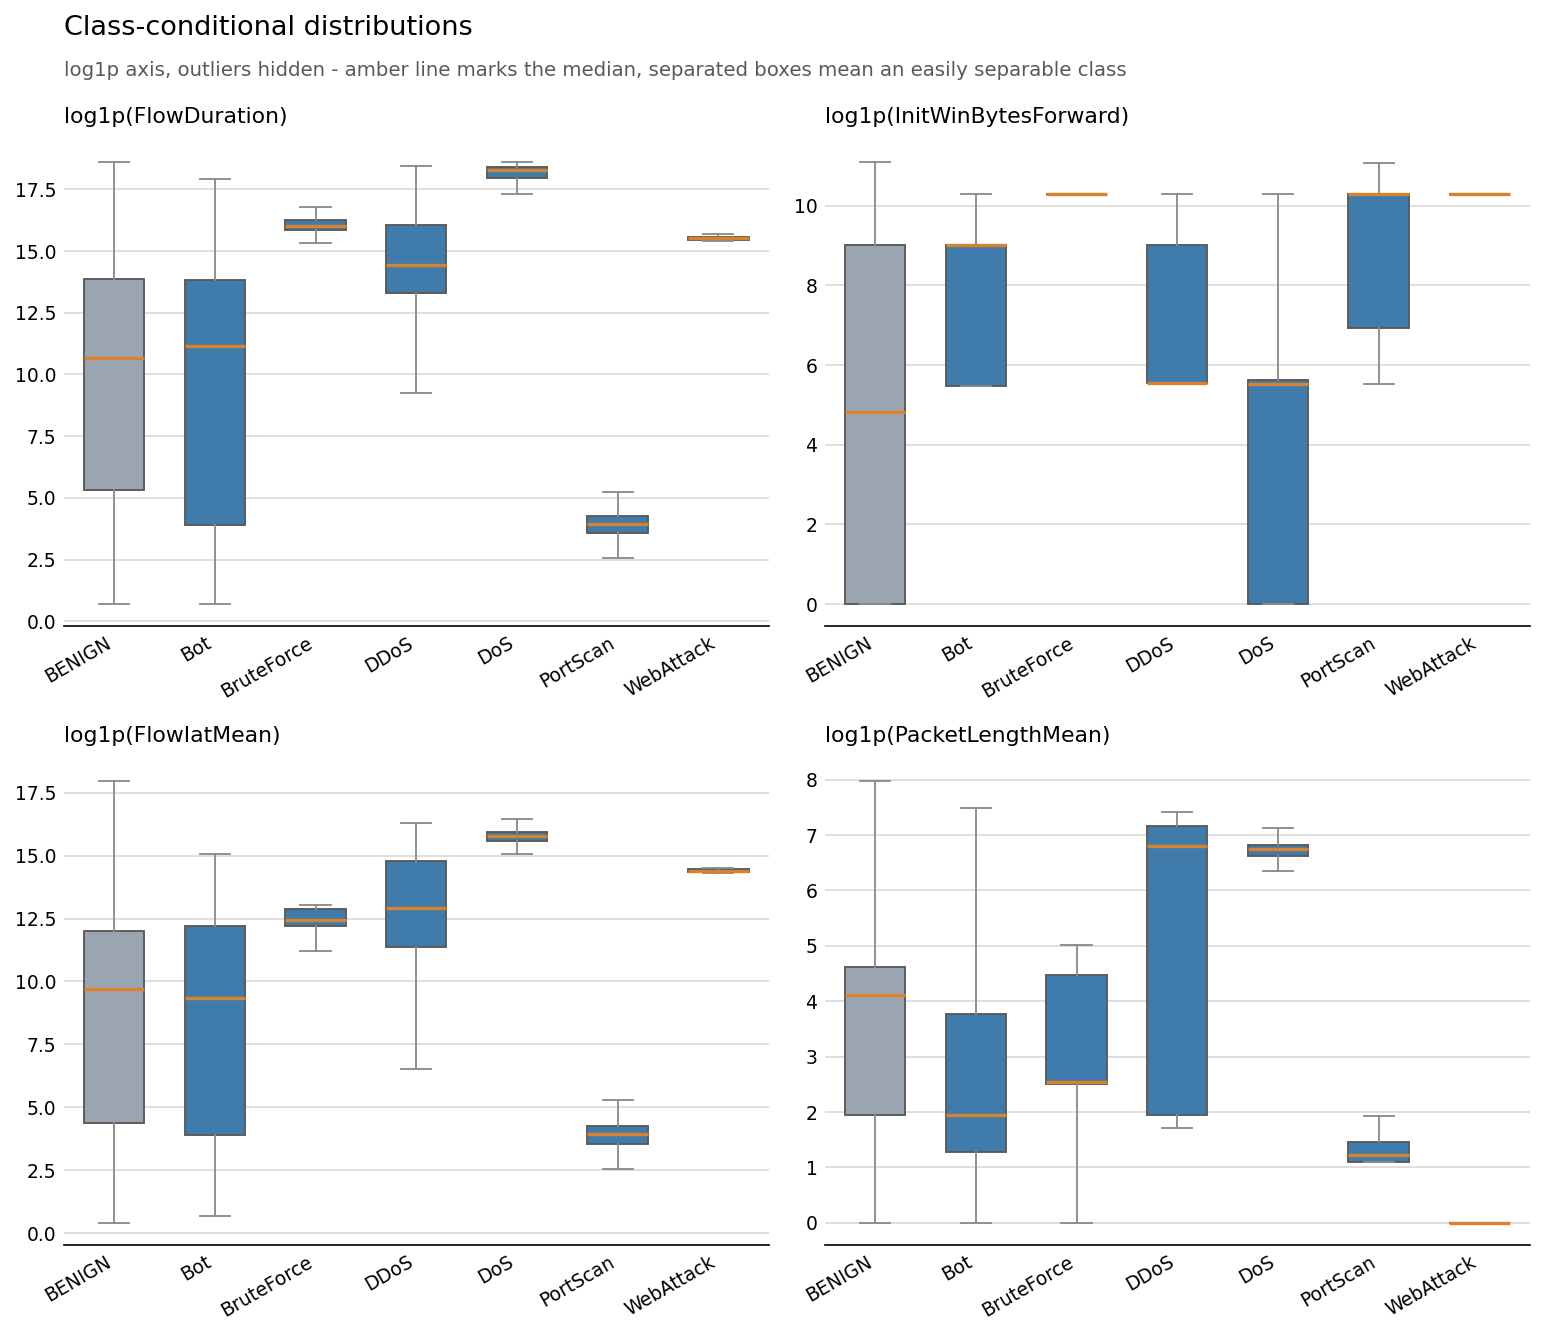

In [19]:
Image(eda.plot_classwise_boxplots(sample, ["FlowDuration", "InitWinBytesForward", "FlowIatMean", "PacketLengthMean"]))

There is a visible separation between attack types. Similarities between a pair of attack types in one plot can be differentiated in other plots. `BENIGN` and `Bot` appear to be most similar. 

1. We should expect a high macro-F1 because the classes are far apart on these axes


**7. Feature redundancy**

69 features, many of which are forward/backward mirrors or restatements of the
same quantity.

In [20]:
# STRONGLY CORRELATED FEATURE PAIRS (sample)
pairs = eda.correlated_pairs(sample, feat, threshold=0.95)
print(f"pairs with |r| > 0.95: {len(pairs)}")
print(f"pairs with |r| > 0.99: {(pairs['AbsCorr'] > 0.99).sum()}")
display(pairs.head(10))

pairs with |r| > 0.95: 72
pairs with |r| > 0.99: 17


,FeatureA,FeatureB,AbsCorr
0,RstFlagCount,EceFlagCount,1.0000
1,TotalFwdPackets,SubflowFwdPackets,1.0000
2,FwdPshFlags,SynFlagCount,1.0000
3,TotalLengthOfFwdPackets,SubflowFwdBytes,1.0000
4,BwdPacketLengthMean,AvgBwdSegmentSize,1.0000
5,FwdPacketLengthMean,AvgFwdSegmentSize,1.0000
6,TotalBackwardPackets,SubflowBwdPackets,1.0000
7,TotalLengthOfBwdPackets,SubflowBwdBytes,1.0000
8,FlowIatMax,FwdIatMax,0.9994
9,PacketLengthMean,AveragePacketSize,0.9993


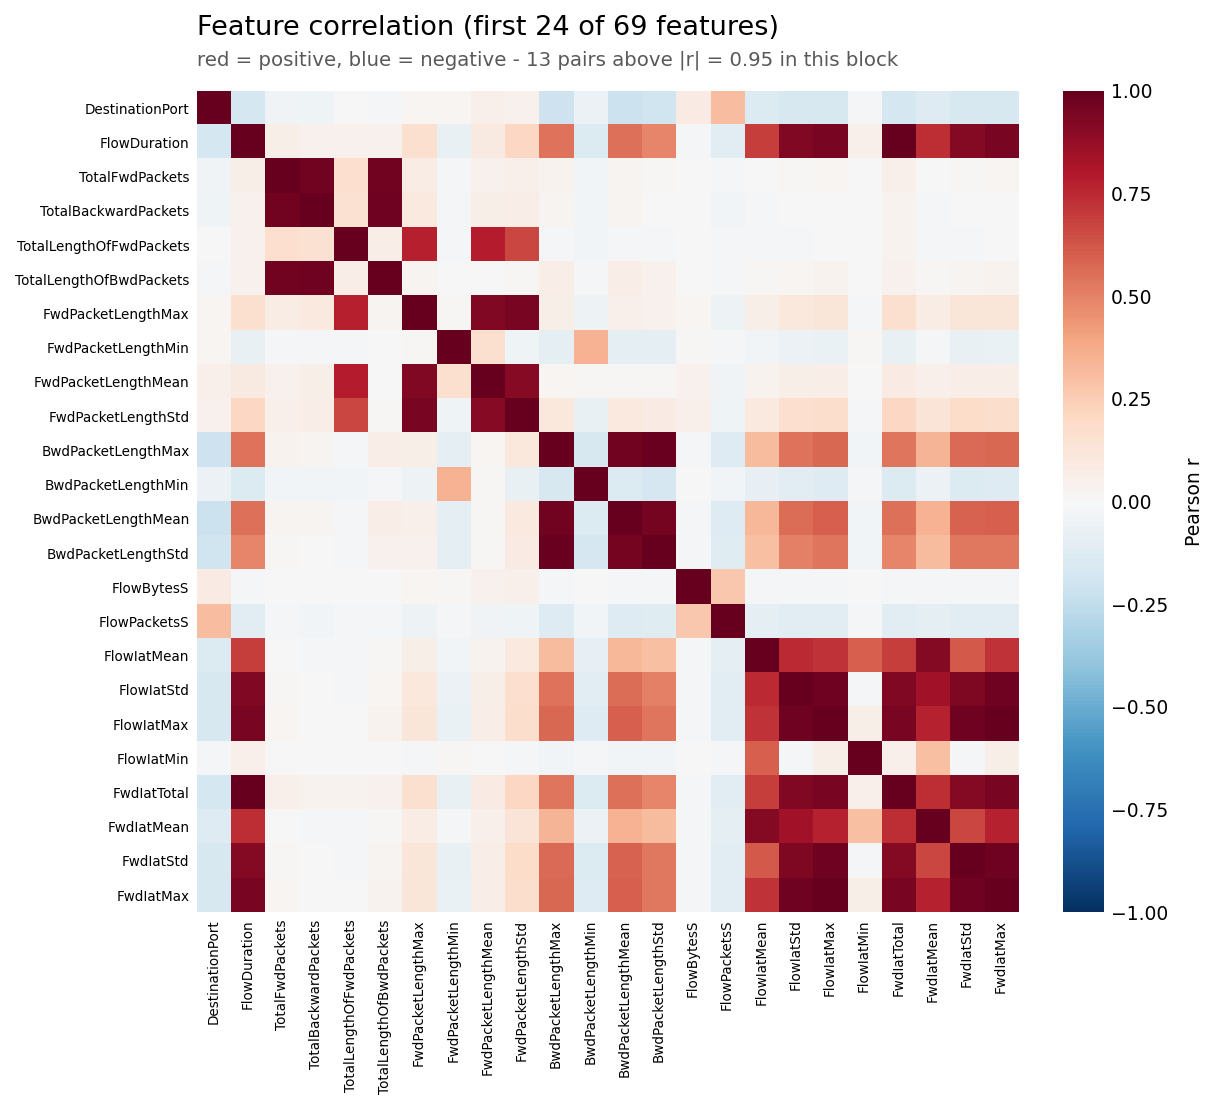

In [ ]:
# VISUALIZE FEATURE CORRELATION
Image(eda.plot_correlation_heatmap(sample, feat))

First check for exact duplicates. 

In [ ]:
# FIND DUPLICATES ON SAMPLE
candidates = eda.identical_feature_pairs(sample, feat)
confirmed = eda.verify_identical_on_full(candidates) # CONFIRM ON FULL DATASET

display(confirmed)
print(f"candidates from the sample: {len(candidates)}")
print(f"confirmed on the full data: {confirmed['IdenticalOnFullData'].sum()}")

,FeatureA,FeatureB,IdenticalOnFullData
0,TotalFwdPackets,SubflowFwdPackets,True
1,TotalBackwardPackets,SubflowBwdPackets,True
2,TotalLengthOfFwdPackets,SubflowFwdBytes,False
3,FwdPacketLengthMean,AvgFwdSegmentSize,True
4,BwdPacketLengthMean,AvgBwdSegmentSize,True
5,FwdPshFlags,SynFlagCount,True
6,FwdUrgFlags,CweFlagCount,True
7,RstFlagCount,EceFlagCount,False


candidates from the sample: 8
confirmed on the full data: 6


2/8 duplicate candidates fail on the full dataset, `TotalLengthOfFwdPackets` / `SubflowFwdBytes` and `RstFlagCount` /
`EceFlagCount`. These should not be dropped. 

1. Since XGBoost is indifferent to collinearity.
2. Duplicated features should be accounted for, otherwise models will treat these variables as double their actual importance. 

**Summary**

In [24]:
summary = pd.DataFrame(
    [
        ("Class balance",
         f"{ratio:,.0f}:1 imbalance; BENIGN is 82.96% of rows",
         "Report macro-F1 + per-class, never accuracy; stratify the split; cap BENIGN in train only"),
        ("Feature scale",
         f"{(skew.abs() > 10).sum()} of {len(feat)} features have |skew| > 10; ranges span ~9 orders of magnitude",
         "StandardScaler inside the pipeline for the linear baseline; raw features for XGBoost"),
        ("Sentinel values",
         "-1 fills 47.8% / 35.7% of the InitWinBytes columns (missing, not measured)",
         "Keep for trees; flag as a distortion caveat on the scaled linear baseline"),
        ("Counter overflow",
         f"{n_bad:,} rows ({pct_bad}%) carry impossible negative duration / rate / header length",
         "Add a sign check to clean_file in stage 1"),
        ("DestinationPort",
         f"{n_ports:,} distinct ports stored as a float, read by models as ordinal",
         "Left as-is (top 3 ports are ~75% of traffic); record top-K encoding as a limitation"),
        ("Separability",
         "Classes differ by orders of magnitude on duration and window size",
         "High macro-F1 is expected; watch BENIGN vs Bot / WebAttack for real confusion"),
        ("Tool fingerprinting",
         "InitWinBytesForward tiers classes by OS/tool default, not by attack concept",
         "State as the central limitation: a within-capture split cannot prove generalisation"),
        ("Redundancy",
         f"{len(pairs)} pairs |r| > 0.95; {confirmed['IdenticalOnFullData'].sum()} confirmed exact aliases",
         "Keep all features for fitting; collapse aliases before reading feature importance"),
    ],
    columns=["Finding", "Evidence", "Decision for Model"],
)

with pd.option_context("display.max_colwidth", None):
    display(summary)

,Finding,Evidence,Decision for Model
0,Class balance,"1,064:1 imbalance; BENIGN is 82.96% of rows","Report macro-F1 + per-class, never accuracy; stratify the split; cap BENIGN in train only"
1,Feature scale,30 of 69 features have |skew| > 10; ranges span ~9 orders of magnitude,StandardScaler inside the pipeline for the linear baseline; raw features for XGBoost
2,Sentinel values,"-1 fills 47.8% / 35.7% of the InitWinBytes columns (missing, not measured)",Keep for trees; flag as a distortion caveat on the scaled linear baseline
3,Counter overflow,"2,910 rows (0.1165%) carry impossible negative duration / rate / header length",Add a sign check to clean_file in stage 1
4,DestinationPort,"53,791 distinct ports stored as a float, read by models as ordinal",Left as-is (top 3 ports are ~75% of traffic); record top-K encoding as a limitation
5,Separability,Classes differ by orders of magnitude on duration and window size,High macro-F1 is expected; watch BENIGN vs Bot / WebAttack for real confusion
6,Tool fingerprinting,"InitWinBytesForward tiers classes by OS/tool default, not by attack concept",State as the central limitation: a within-capture split cannot prove generalisation
7,Redundancy,72 pairs |r| > 0.95; 6 confirmed exact aliases,Keep all features for fitting; collapse aliases before reading feature importance
